In [20]:
import pandas as pd
import joblib
import numpy as np


model = joblib.load("../src/models/churn_model.pkl")
df = pd.read_csv("../data/raw/IBM Teleco Churn Dataset.csv")

df.drop("customerID", axis=1, inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].median())
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

X = df.drop("Churn", axis=1)
y = df["Churn"]
cat_cols = X.select_dtypes(include=["object", "string"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# make every column numeric for SHAP
X = X.astype(float)

print(X.dtypes.unique())
print(X.shape)

[dtype('float64')]
(7043, 30)


In [21]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(7043, 30, 2)


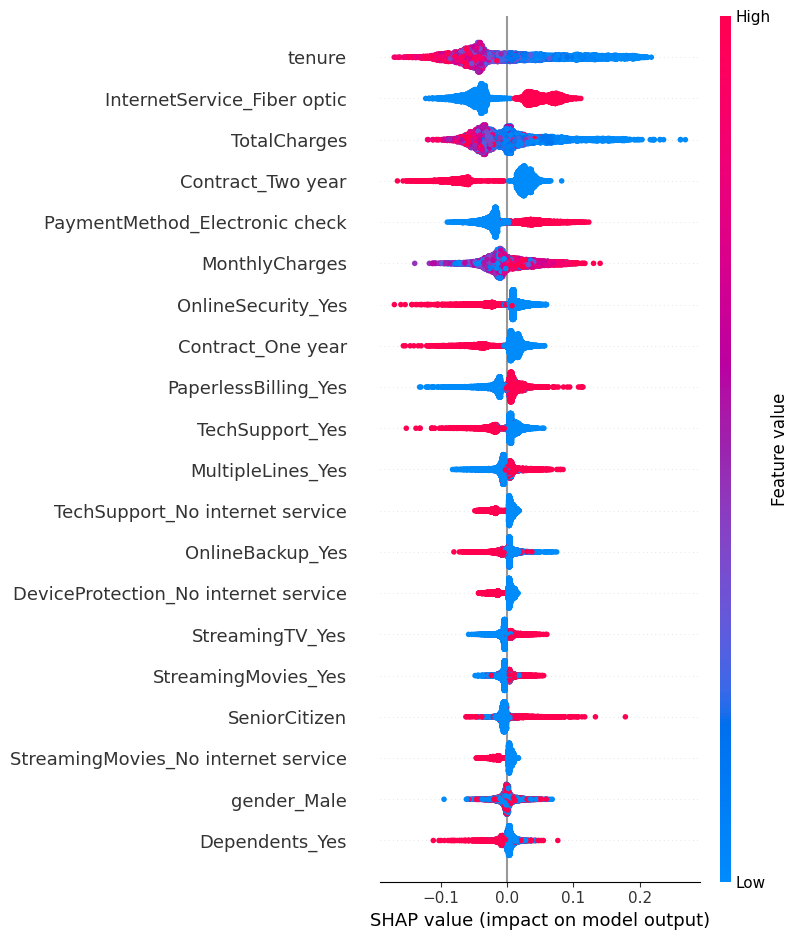

In [22]:
sv = np.array(shap_values)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X)
elif sv.ndim == 3:
    shap.summary_plot(sv[:, :, 1], X)
else:
    shap.summary_plot(shap_values, X)

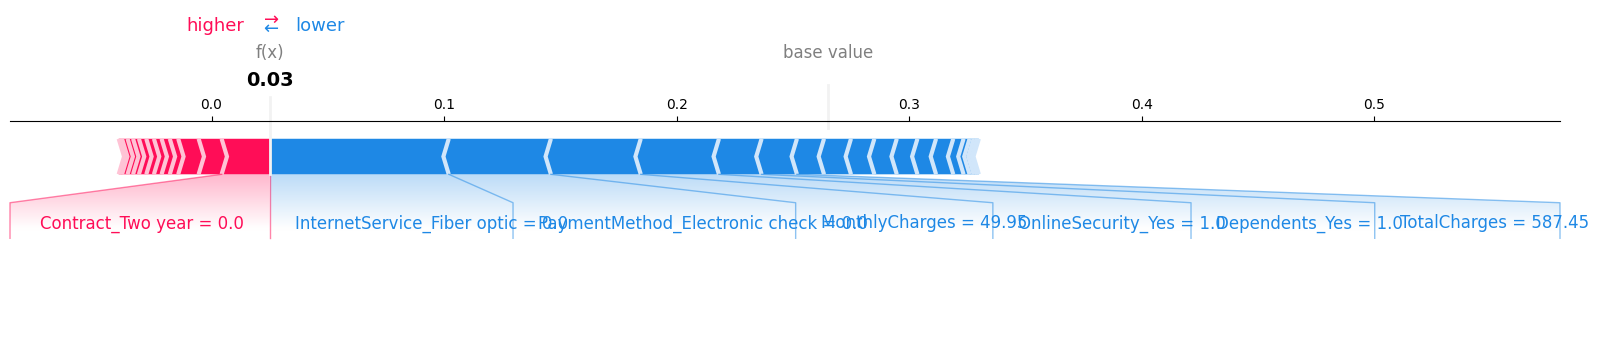

In [24]:
index = 10
sv = np.array(shap_values)

if isinstance(shap_values, list):
    single_shap = shap_values[1][index]
    base_value = explainer.expected_value[1]
elif sv.ndim == 3:
    single_shap = sv[index, :, 1]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    single_shap = shap_values[index]
    base_value = explainer.expected_value

shap.force_plot(
    base_value,
    single_shap,
    X.iloc[index],
    matplotlib=True
)

In [13]:

probs = model.predict_proba(X)[:,1]


def risk_category(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

df["Churn_Prob"] = probs
df["Risk_Level"] = df["Churn_Prob"].apply(risk_category)


df["Risk_Level"].value_counts()

Risk_Level
Low Risk       4952
High Risk      1410
Medium Risk     681
Name: count, dtype: int64

In [14]:
def retention_action(row):
    actions = []
    
    if row["Contract"] == "Month-to-month":
        actions.append("Offer long-term contract discount")
        
    if row["MonthlyCharges"] > 70:
        actions.append("Provide discount or bundle offer")
        
    if row["tenure"] < 12:
        actions.append("Onboarding support / engagement program")
        
    if row["TechSupport"] == "No":
        actions.append("Offer free tech support trial")
        
    return ", ".join(actions)

df["Retention_Action"] = df.apply(retention_action, axis=1)


df[["Churn_Prob", "Risk_Level", "Retention_Action"]].head(10)

,Churn_Prob,Risk_Level,Retention_Action
0,0.320,Medium Risk,"Offer long-term contract discount, Onboarding ..."
1,0.000,Low Risk,Offer free tech support trial
2,0.845,High Risk,"Offer long-term contract discount, Onboarding ..."
3,0.005,Low Risk,
4,0.835,High Risk,"Offer long-term contract discount, Provide dis..."
5,0.995,High Risk,"Offer long-term contract discount, Provide dis..."
6,0.505,Medium Risk,"Offer long-term contract discount, Provide dis..."
7,0.125,Low Risk,"Offer long-term contract discount, Onboarding ..."
8,0.890,High Risk,"Offer long-term contract discount, Provide dis..."
9,0.015,Low Risk,Offer free tech support trial
